### Paso 1: Planteamiento del problema y recopilación de datos:

Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre diabetes.csv. Puedes cargarlo en el código directamente desde el siguiente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

total_data = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv")
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Paso 2: Exploración y Limpieza

In [2]:
total_data.shape

(768, 9)

In [3]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


- Existen 768 filas en este dataset 
- Ninguna de las 9 columnas cuenta con valores nulos.
- El data set cuanta con 9 variables numericas, aunque Outcome se puede considerar como categorica.

# Verificamos que no haya duplicados en el dataset

In [4]:
total_data.duplicated().sum()
np.int64(0)
print("Filas duplicadas exactas:", total_data.duplicated().sum())

Filas duplicadas exactas: 0


# Paso 3: Análisis de variables univariantes

- Análicemos a través de histograma el comportamiento de la variable categorica

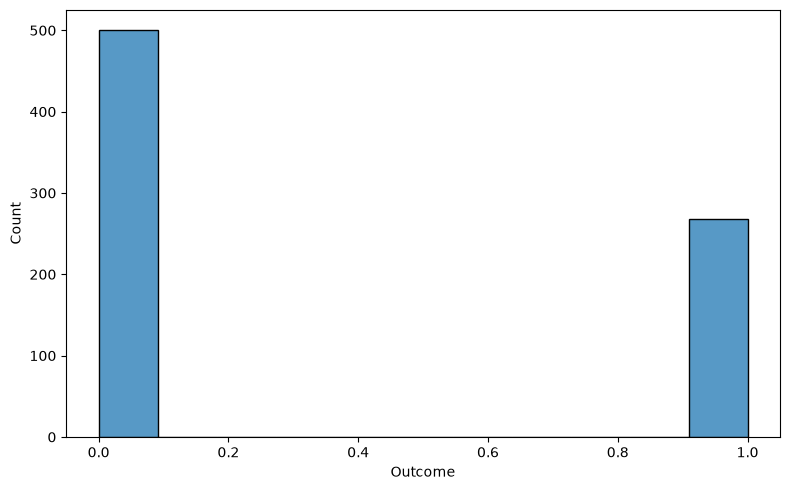

In [5]:
# Crear una única figura sin subplots múltiples
fig, axis = plt.subplots(figsize=(8, 5))

# Crear el histograma
sns.histplot(data = total_data, x = "Outcome", ax = axis)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- Podemos detallar que aproximadamente 500 (65%) de los registros no tienen diabetes.
## Análisis sobre variables numéricas:

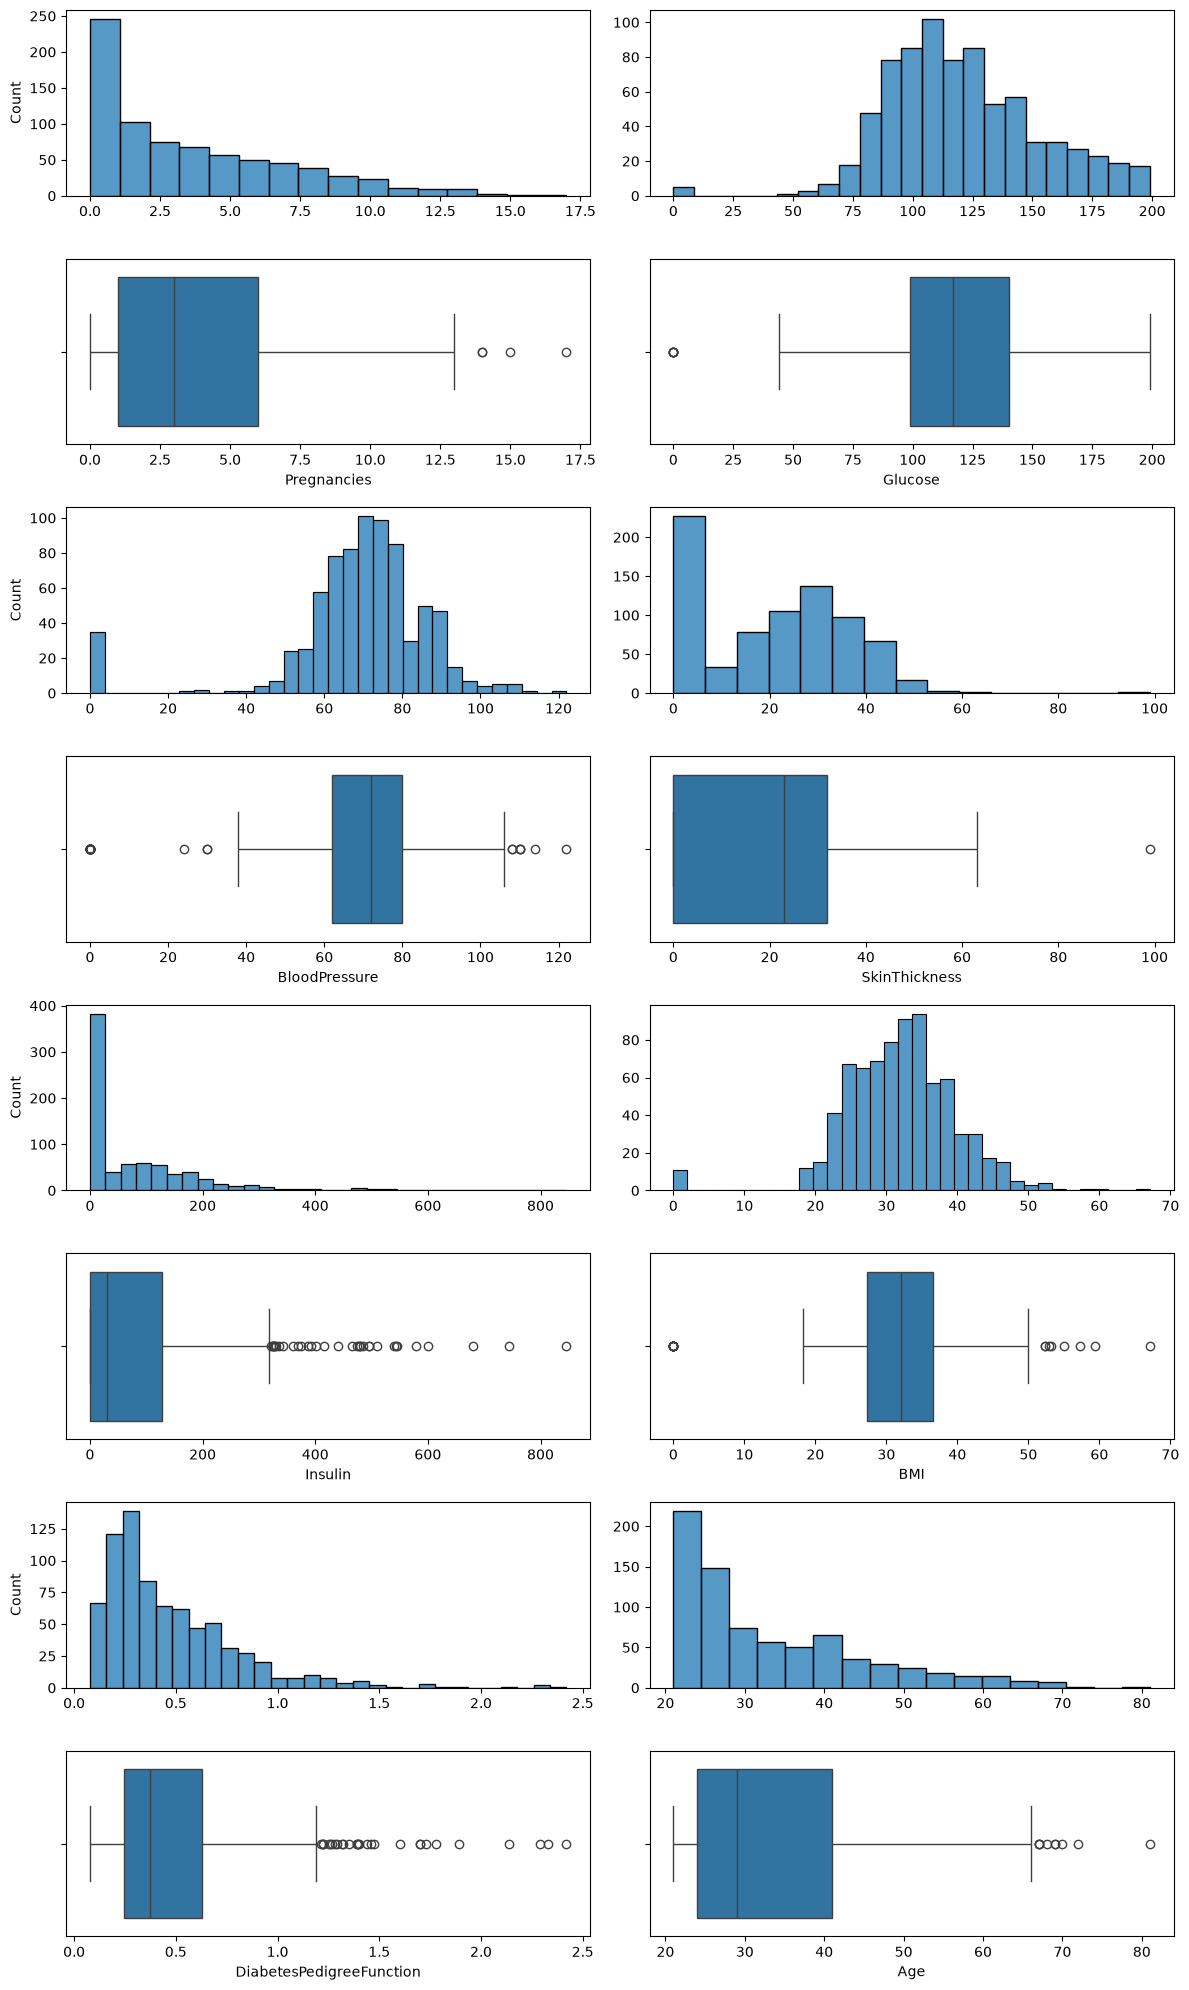

In [6]:
fig, axis = plt.subplots(8, 2, figsize = (12, 20))

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = total_data, x = "Pregnancies").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = total_data, x = "Pregnancies")
sns.histplot(ax = axis[0, 1], data = total_data, x = "Glucose").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = total_data, x = "Glucose")
sns.histplot(ax = axis[2, 0], data = total_data, x = "BloodPressure").set(xlabel = None)
sns.boxplot(ax = axis[3, 0], data = total_data, x = "BloodPressure")
sns.histplot(ax = axis[2, 1], data = total_data, x = "SkinThickness").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = total_data, x = "SkinThickness")
sns.histplot(ax = axis[4, 0], data = total_data, x = "Insulin").set(xlabel = None)
sns.boxplot(ax = axis[5, 0], data = total_data, x = "Insulin")
sns.histplot(ax = axis[4, 1], data = total_data, x = "BMI").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 1], data = total_data, x = "BMI")
sns.histplot(ax = axis[6, 0], data = total_data, x = "DiabetesPedigreeFunction").set(xlabel = None)
sns.boxplot(ax = axis[7, 0], data = total_data, x = "DiabetesPedigreeFunction")
sns.histplot(ax = axis[6, 1], data = total_data, x = "Age").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[7, 1], data = total_data, x = "Age")

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- Notamos que variables como "Glucose", "BloodPressure", "SkinThickness", "Insulin" y "BMI" contienen una cantidad importante de ceros ($0$), lo cual es fisiológicamente imposible para una persona viva, indicando que en realidad son datos faltantes encubiertos.Por lo anterior, primero convertiremos dichos ceros en valores nulos (NaN) para evitar que distorsionen los cálculos, y posteriormente realizaremos una sustitución utilizando la mediana de cada columna.

In [7]:
# Definimos las columnas que contienen ceros fisiológicamente imposibles
cols_to_fix = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# 1. Convertimos los ceros en valores nulos (NaN) para evitar distorsiones
total_data[cols_to_fix] = total_data[cols_to_fix].replace(0, np.nan)

# 2. Calculamos la mediana de cada columna (ignorando los NaN) y realizamos la sustitución
for col in cols_to_fix:
  median_val = total_data[col].median()
  total_data[col] = total_data[col].fillna(median_val)

# Verificamos que ya no queden ceros en estas columnas
print("Ceros restantes por columna:")
print((total_data[cols_to_fix] == 0).sum())

Ceros restantes por columna:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## Volvemos a gráficar las variables numéricas con la sustitución

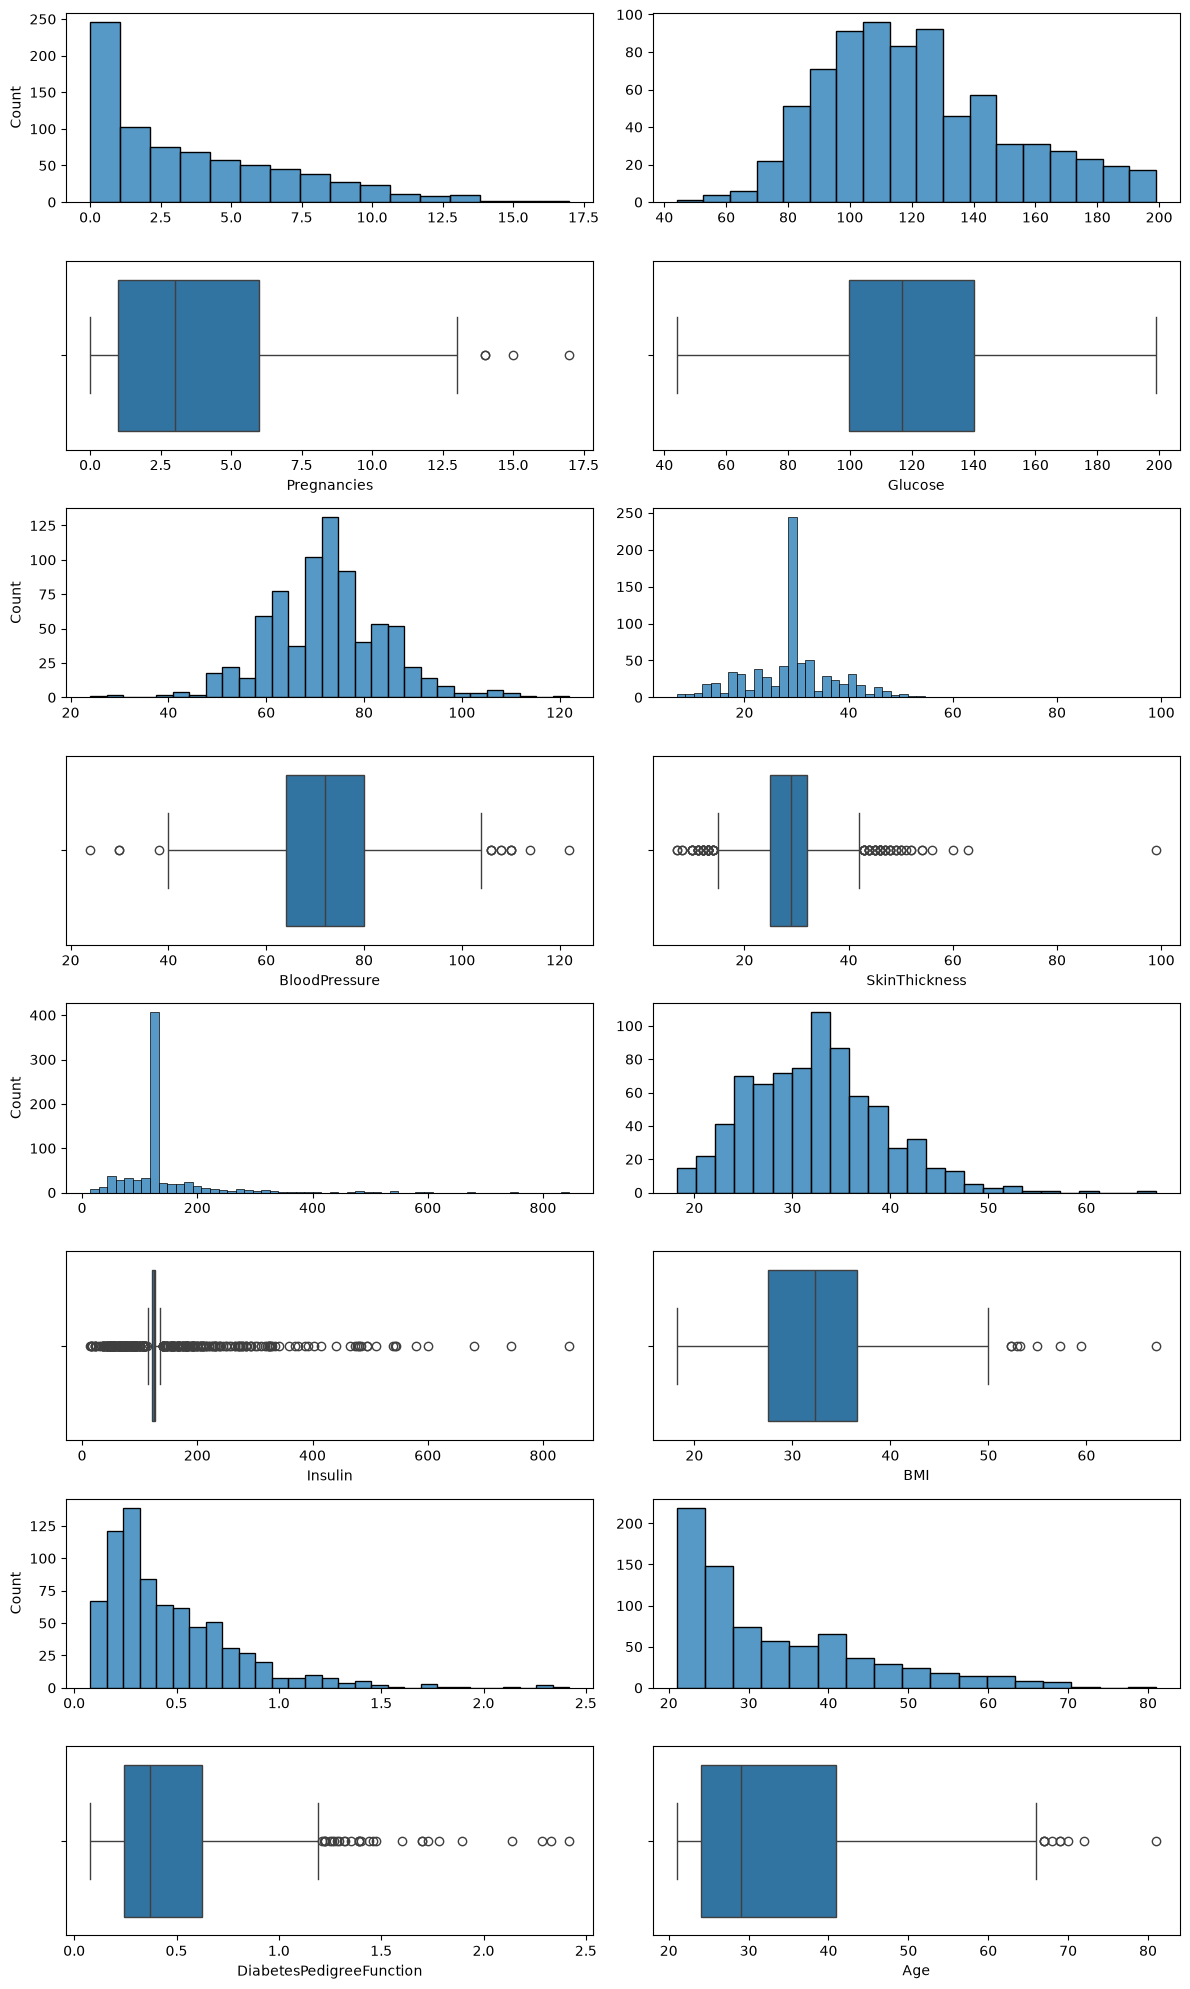

In [8]:
fig, axis = plt.subplots(8, 2, figsize = (12, 20))

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = total_data, x = "Pregnancies").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = total_data, x = "Pregnancies")
sns.histplot(ax = axis[0, 1], data = total_data, x = "Glucose").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = total_data, x = "Glucose")
sns.histplot(ax = axis[2, 0], data = total_data, x = "BloodPressure").set(xlabel = None)
sns.boxplot(ax = axis[3, 0], data = total_data, x = "BloodPressure")
sns.histplot(ax = axis[2, 1], data = total_data, x = "SkinThickness").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = total_data, x = "SkinThickness")
sns.histplot(ax = axis[4, 0], data = total_data, x = "Insulin").set(xlabel = None)
sns.boxplot(ax = axis[5, 0], data = total_data, x = "Insulin")
sns.histplot(ax = axis[4, 1], data = total_data, x = "BMI").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 1], data = total_data, x = "BMI")
sns.histplot(ax = axis[6, 0], data = total_data, x = "DiabetesPedigreeFunction").set(xlabel = None)
sns.boxplot(ax = axis[7, 0], data = total_data, x = "DiabetesPedigreeFunction")
sns.histplot(ax = axis[6, 1], data = total_data, x = "Age").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[7, 1], data = total_data, x = "Age")

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- **Pregnancies (Embarazos):** presenta un claro sesgo positivo hacia la derecha. La gran mayoría de los registros se concentran entre 0 y 4 embarazos, con una disminución gradual a medida que aumenta el número, alcanzando valores máximos atípicos superiores a 15.
- **Glucose (Glucosa):** muestra una forma cercana a la distribución normal (campana de Gauss) tras haber eliminado los ceros anómalos. La concentración principal se sitúa en rangos considerados normales/moderados, con una cola derecha que extiende los valores hacia niveles hiperglucémicos.
- **BloodPressure (Presión Sanguínea):** tras limpiar los ceros fisiológicamente imposibles, los valores se agrupan simétricamente en torno a la media/mediana (valores de presión diastólica típicos de la muestra).
- **SkinThickness (Grosor de Piel):** presenta un sesgo positivo marcado con una acumulación de datos en valores bajos y una cola extendida hacia valores altos en el diagrama de caja.
- **Insulin (Insulina):** es la variable que presentaba mayor cantidad de ceros ocultos. Una vez imputada, muestra una distribución fuertemente sesgada a la derecha con una alta densidad de valores en rangos bajos y múltiples puntos atípicos superiores en el boxplot.
- **BMI (Índice de Masa Corporal):** distribución bastante simétrica y acampanada, centrada en rangos de sobrepeso/obesidad según los estándares clínicos, con pocos valores extremos aislados.
- **DiabetesPedigreeFunction (Función de Pedigrí de Diabetes):** muestra un sesgo positivo pronunciado. La gran mayoría de los valores se concentran en la parte baja de la escala, con una cola larga y varios valores atípicos hacia arriba.
- **Age (Edad):** fuerte sesgo positivo. La población del dataset es mayoritariamente joven a de mediana edad (concentrada en el rango inferior), disminuyendo drásticamente la frecuencia en adultos mayores.

## Análisis de variables multivariante:

### Análisis numérico-numérico:

##### Outcome - (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age)

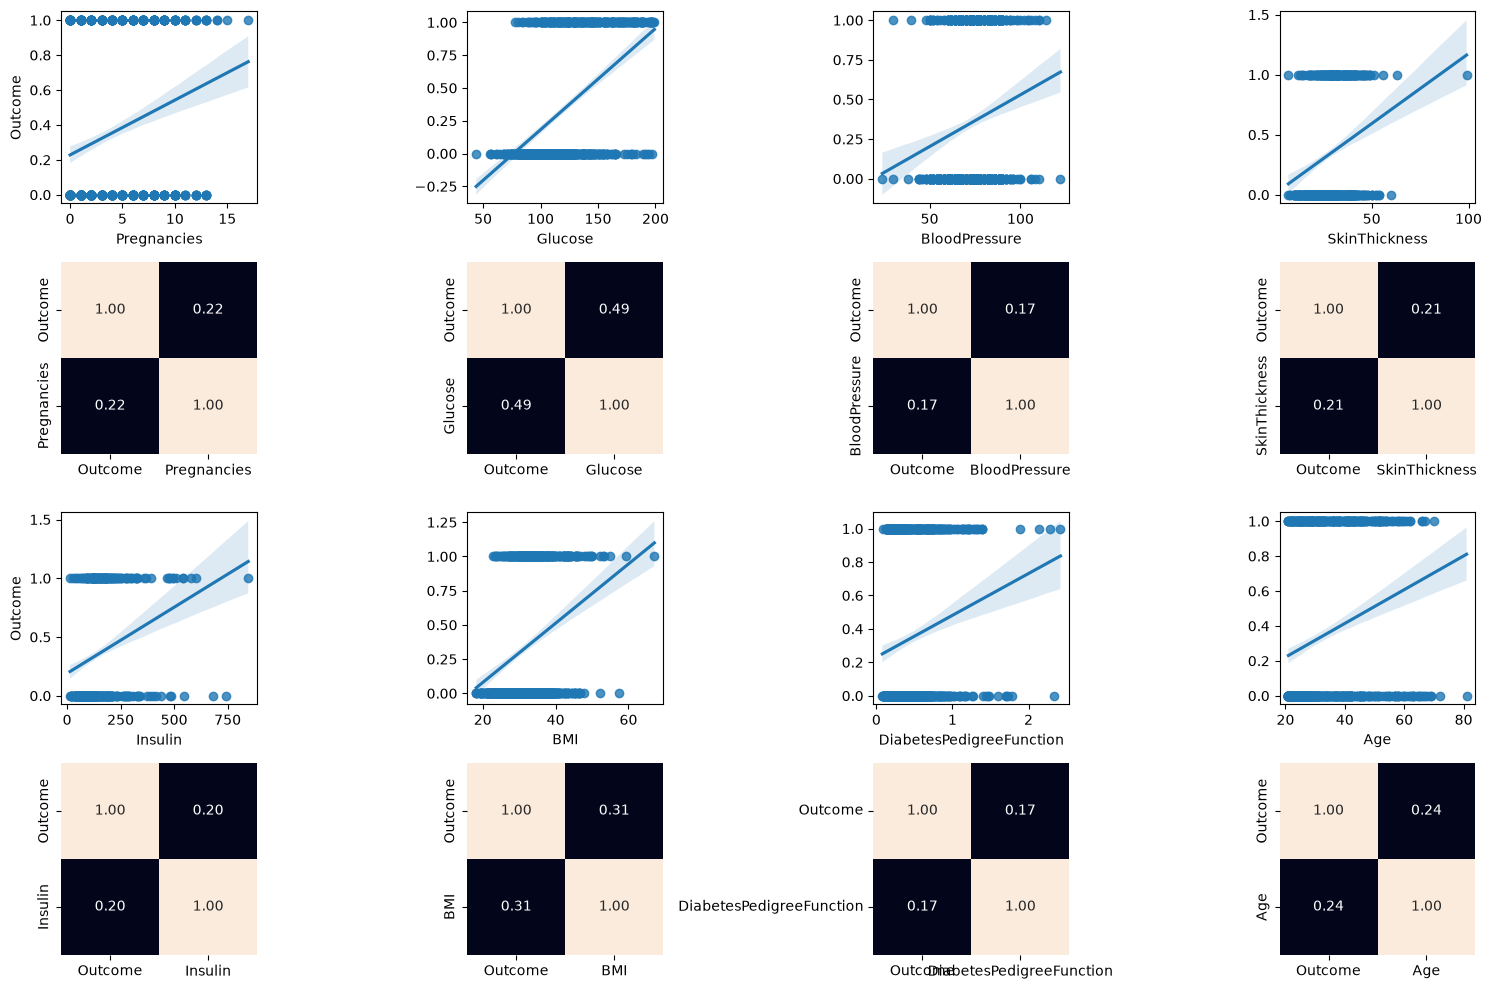

In [9]:
fig, axis = plt.subplots(4, 4, figsize = (15, 10))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = total_data, x = "Pregnancies", y = "Outcome")
sns.heatmap(total_data[["Outcome", "Pregnancies"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
sns.regplot(ax = axis[0, 1], data = total_data, x = "Glucose", y = "Outcome").set(ylabel=None)
sns.heatmap(total_data[["Outcome", "Glucose"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)
sns.regplot(ax = axis[0, 2], data = total_data, x = "BloodPressure", y = "Outcome").set(ylabel=None)
sns.heatmap(total_data[["Outcome", "BloodPressure"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 2], cbar = False)
sns.regplot(ax = axis[0, 3], data = total_data, x = "SkinThickness", y = "Outcome").set(ylabel=None)
sns.heatmap(total_data[["Outcome", "SkinThickness"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 3], cbar = False)
sns.regplot(ax = axis[2, 0], data = total_data, x = "Insulin", y = "Outcome")
sns.heatmap(total_data[["Outcome", "Insulin"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0], cbar = False)
sns.regplot(ax = axis[2, 1], data = total_data, x = "BMI", y = "Outcome").set(ylabel=None)
sns.heatmap(total_data[["Outcome", "BMI"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 1], cbar = False)
sns.regplot(ax = axis[2, 2], data = total_data, x = "DiabetesPedigreeFunction", y = "Outcome").set(ylabel=None)
sns.heatmap(total_data[["Outcome", "DiabetesPedigreeFunction"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 2], cbar = False)
sns.regplot(ax = axis[2, 3], data = total_data, x = "Age", y = "Outcome").set(ylabel=None)
sns.heatmap(total_data[["Outcome", "Age"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 3], cbar = False)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

El análisis conjunto de los diagramas de dispersión y las matrices de correlación revela que la Glucose presenta la relación lineal más fuerte con el diagnóstico de diabetes (Outcome), con un coeficiente de correlación de $0.49$, seguida por variables secundarias como el BMI ($0.33$) y la Age ($0.24$). Por el contrario, factores como BloodPressure y SkinThickness muestran correlaciones notablemente más bajas ($0.17$ y $0.21$, respectivamente), lo que indica que, si bien todas las variables limpiadas aportan contexto biológico al EDA, la glucosa y el índice de masa corporal se perfilan como los predictores cuantitativos más determinantes de cara al posterior entrenamiento del árbol de decisión.

## Análisis de correlaciones:
- Aqui confirmamos lo que comentado en el bloique anterior

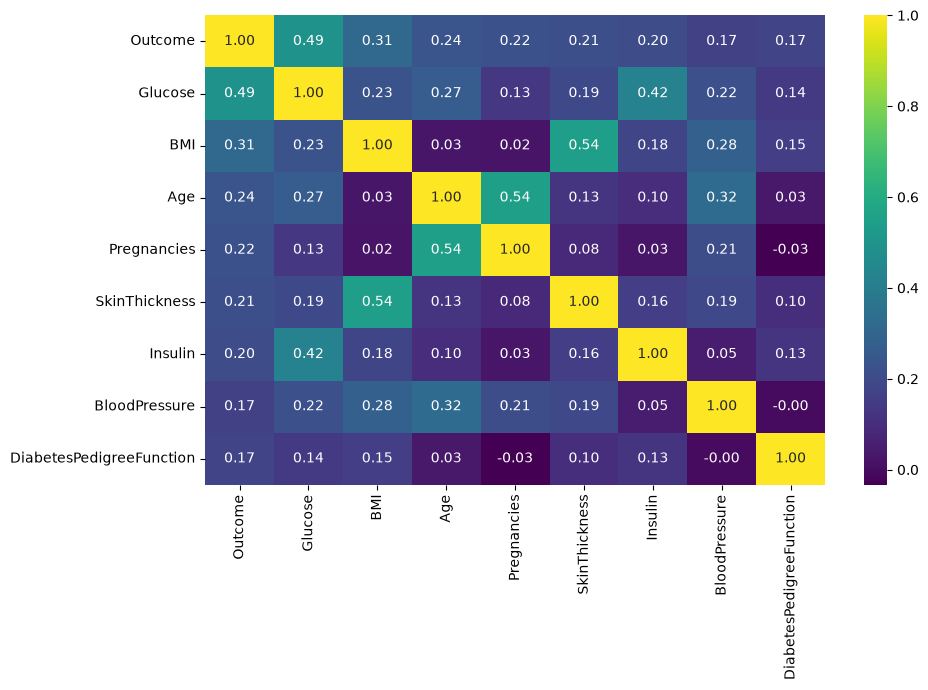

In [10]:
cols_num = ["Outcome", "Glucose", "BMI", "Age", "Pregnancies", "SkinThickness", "Insulin", "BloodPressure", "DiabetesPedigreeFunction"]  # todas numéricas
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(total_data[cols_num].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

Ingeniería de características:

#### Análisis de outliers:

In [11]:
FINAL_COLS = ["Outcome", "Glucose", "BMI", "Age", "Pregnancies", "SkinThickness", "Insulin", "BloodPressure", "DiabetesPedigreeFunction"]
total_data = total_data[FINAL_COLS]

In [12]:
total_data.columns

Index(['Outcome', 'Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness',
       'Insulin', 'BloodPressure', 'DiabetesPedigreeFunction'],
      dtype='str')

In [13]:
total_data.describe()

,Outcome,Glucose,BMI,Age,Pregnancies,SkinThickness,Insulin,BloodPressure,DiabetesPedigreeFunction
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.348958,121.656250,32.455208,33.240885,3.845052,29.108073,140.671875,72.386719,0.471876
std,0.476951,30.438286,6.875177,11.760232,3.369578,8.791221,86.383060,12.096642,0.331329
min,0.000000,44.000000,18.200000,21.000000,0.000000,7.000000,14.000000,24.000000,0.078000
25%,0.000000,99.750000,27.500000,24.000000,1.000000,25.000000,121.500000,64.000000,0.243750
50%,0.000000,117.000000,32.300000,29.000000,3.000000,29.000000,125.000000,72.000000,0.372500
75%,1.000000,140.250000,36.600000,41.000000,6.000000,32.000000,127.250000,80.000000,0.626250
max,1.000000,199.000000,67.100000,81.000000,17.000000,99.000000,846.000000,122.000000,2.420000


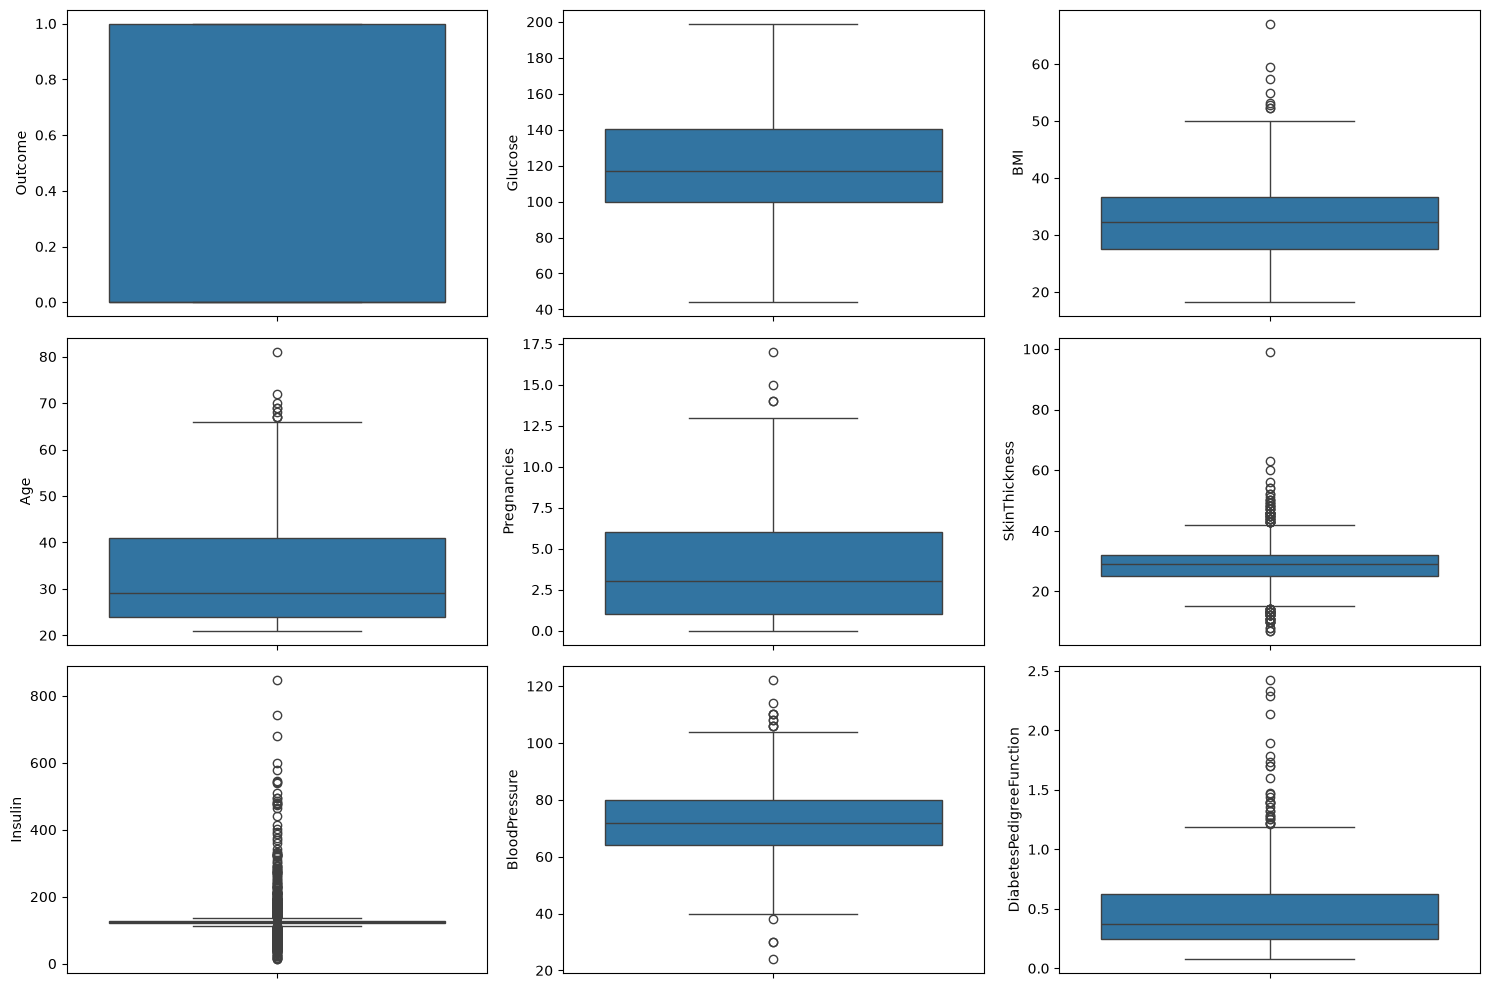

In [14]:
fig, axis = plt.subplots(3, 3, figsize = (15, 10))

sns.boxplot(ax = axis[0, 0], data = total_data, y = "Outcome")
sns.boxplot(ax = axis[0, 1], data = total_data, y = "Glucose")
sns.boxplot(ax = axis[0, 2], data = total_data, y = "BMI")
sns.boxplot(ax = axis[1, 0], data = total_data, y = "Age")
sns.boxplot(ax = axis[1, 1], data = total_data, y = "Pregnancies")
sns.boxplot(ax = axis[1, 2], data = total_data, y = "SkinThickness")
sns.boxplot(ax = axis[2, 0], data = total_data, y = "Insulin")
sns.boxplot(ax = axis[2, 1], data = total_data, y = "BloodPressure")
sns.boxplot(ax = axis[2, 2], data = total_data, y = "DiabetesPedigreeFunction")

plt.tight_layout()

plt.show()

Por los momentos no vamos a eliminar los valores atípicos, como es un modelo de arboles de decisión éstos son inmunes a los valores atípicos. Un valor extremo simplemente caerá en el nodo final de la rama sin afectar el cálculo de los demás nodos. Si lo eliminamos, lo único que lograremos será perder información valiosa de pacientes reales.
#### Análisis de valores faltantes:

In [15]:
total_data.isnull().sum().sort_values(ascending=False)

Outcome                     0
Glucose                     0
BMI                         0
Age                         0
Pregnancies                 0
SkinThickness               0
Insulin                     0
BloodPressure               0
DiabetesPedigreeFunction    0
dtype: int64

- Ahora definimos nuestras variables predictoras y target

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Recargamos los datos crudos para partir de cero sin el leakage anterior
raw_data = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv")

cols_to_fix = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
raw_data[cols_to_fix] = raw_data[cols_to_fix].replace(0, np.nan)

predictoras = ["Glucose", "BMI", "Age", "Pregnancies", "SkinThickness", "Insulin", "BloodPressure", "DiabetesPedigreeFunction"]
target = "Outcome"

X = raw_data[predictoras]
y = raw_data[target]

# 1. Split PRIMERO, con stratify para mantener la proporción de Outcome
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)
X_train = X_train.copy()
X_test = X_test.copy()

# 2. Imputamos usando SOLO la mediana de TRAIN (evita fuga de información)
medians_train = X_train[cols_to_fix].median()
X_train[cols_to_fix] = X_train[cols_to_fix].fillna(medians_train)
X_test[cols_to_fix] = X_test[cols_to_fix].fillna(medians_train)

print("Proporción de Outcome en train:", round(y_train.mean(), 3))
print("Proporción de Outcome en test: ", round(y_test.mean(), 3))

# ESTO ES LO QUE SALE DE ESTE PASO
# X_train
# X_test
# y_train
# y_test

Proporción de Outcome en train: 0.349
Proporción de Outcome en test:  0.351


#### Escalado de valores:
- Al ser un modelo de arboles de decisiones no es necesario realizar el escalado de valores.
- Procedemos a guardar los ficheros generados.

In [4]:
# GUARDARLO -> TODO <-

# PATH = "/data/processed"
PATH = "/workspaces/Random_Forest_Sahid_Leal/data/processed"

# DATASETS QUE HE IDO ACUMULANDO EN LOS PASOS 4 Y 5
X_train.to_excel(f"{PATH}/X_train.xlsx", index = False)

X_test.to_excel(f"{PATH}/X_test.xlsx", index = False)


y_train.to_excel(f"{PATH}/y_train.xlsx", index = False)
y_test.to_excel(f"{PATH}/y_test.xlsx", index = False)


### Machine Learning
- Como vamos a trabajar con un modelo de Arbol de decición no tenemos que elegir el mejor dataset ya que solo tenemos un dataset.


In [5]:
PATH = "/workspaces/Random_Forest_Sahid_Leal/data/processed"

X_train = pd.read_excel(f"{PATH}/X_train.xlsx")
X_test = pd.read_excel(f"{PATH}/X_test.xlsx")

y_train = pd.read_excel(f"{PATH}/y_train.xlsx").squeeze()  # Convertir a Series si es necesario
y_test = pd.read_excel(f"{PATH}/y_test.xlsx").squeeze()  # Convertir a Series si es necesario

## Procedemos a entrenar el modelo y calcular sus métricas:
- Recordemos que el proyecto nos solicita modificar la función de cálculo de la pureza de los nodos, es decir ver la diferencia de criteios: "gini" y "entropy".
- Luego analizamos sus métricas y graficamos los arboles

--- Gini ---
Accuracy train: 1.0000
Accuracy test:  0.6883
ROC AUC test:   0.6791
              precision    recall  f1-score   support

 No Diabetes       0.79      0.71      0.75       100
    Diabetes       0.55      0.65      0.59        54

    accuracy                           0.69       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.70      0.69      0.69       154


--- Entropy ---
Accuracy train: 1.0000
Accuracy test:  0.7078
ROC AUC test:   0.6898
              precision    recall  f1-score   support

 No Diabetes       0.79      0.75      0.77       100
    Diabetes       0.58      0.63      0.60        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.71      0.71      0.71       154




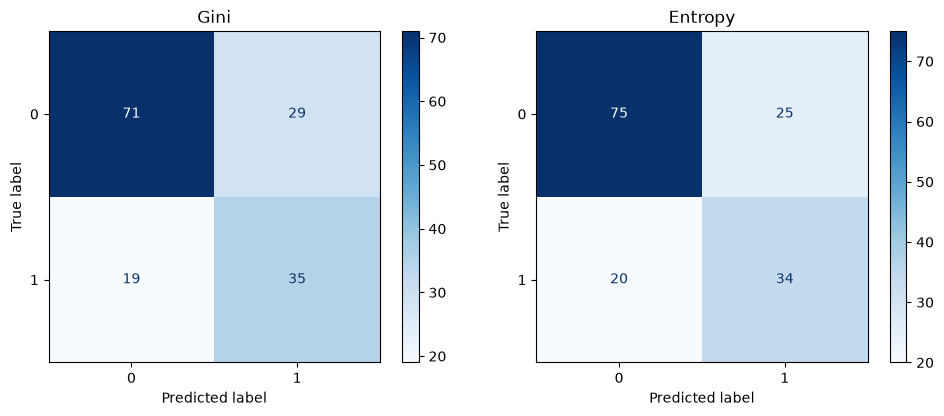

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_gini = DecisionTreeClassifier(criterion="gini", random_state=10)
model_gini.fit(X_train, y_train)

model_entropy = DecisionTreeClassifier(criterion="entropy", random_state=10)
model_entropy.fit(X_train, y_train)

modelos = {"Gini": model_gini, "Entropy": model_entropy}

for nombre, modelo in modelos.items():
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    y_test_proba = modelo.predict_proba(X_test)[:, 1]

    print(f"--- {nombre} ---")
    print(f"Accuracy train: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Accuracy test:  {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"ROC AUC test:   {roc_auc_score(y_test, y_test_proba):.4f}")
    print(classification_report(y_test, y_test_pred, target_names=["No Diabetes", "Diabetes"]))
    print()

# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_estimator(model_gini, X_test, y_test, ax=axes[0], cmap="Blues")
axes[0].set_title("Gini")
ConfusionMatrixDisplay.from_estimator(model_entropy, X_test, y_test, ax=axes[1], cmap="Blues")
axes[1].set_title("Entropy")
plt.tight_layout()
plt.show()

- El criterio Entropy obtuvo mejor accuracy (70.78% vs 68.83%) y mejor ROC AUC (0.69 vs 0.68) que Gini. Sin embargo, Gini logra un recall ligeramente superior para la clase Diabetes (0.65 vs 0.63), lo cual es clínicamente relevante porque implica menos falsos negativos (menos diabéticos sin detectar).

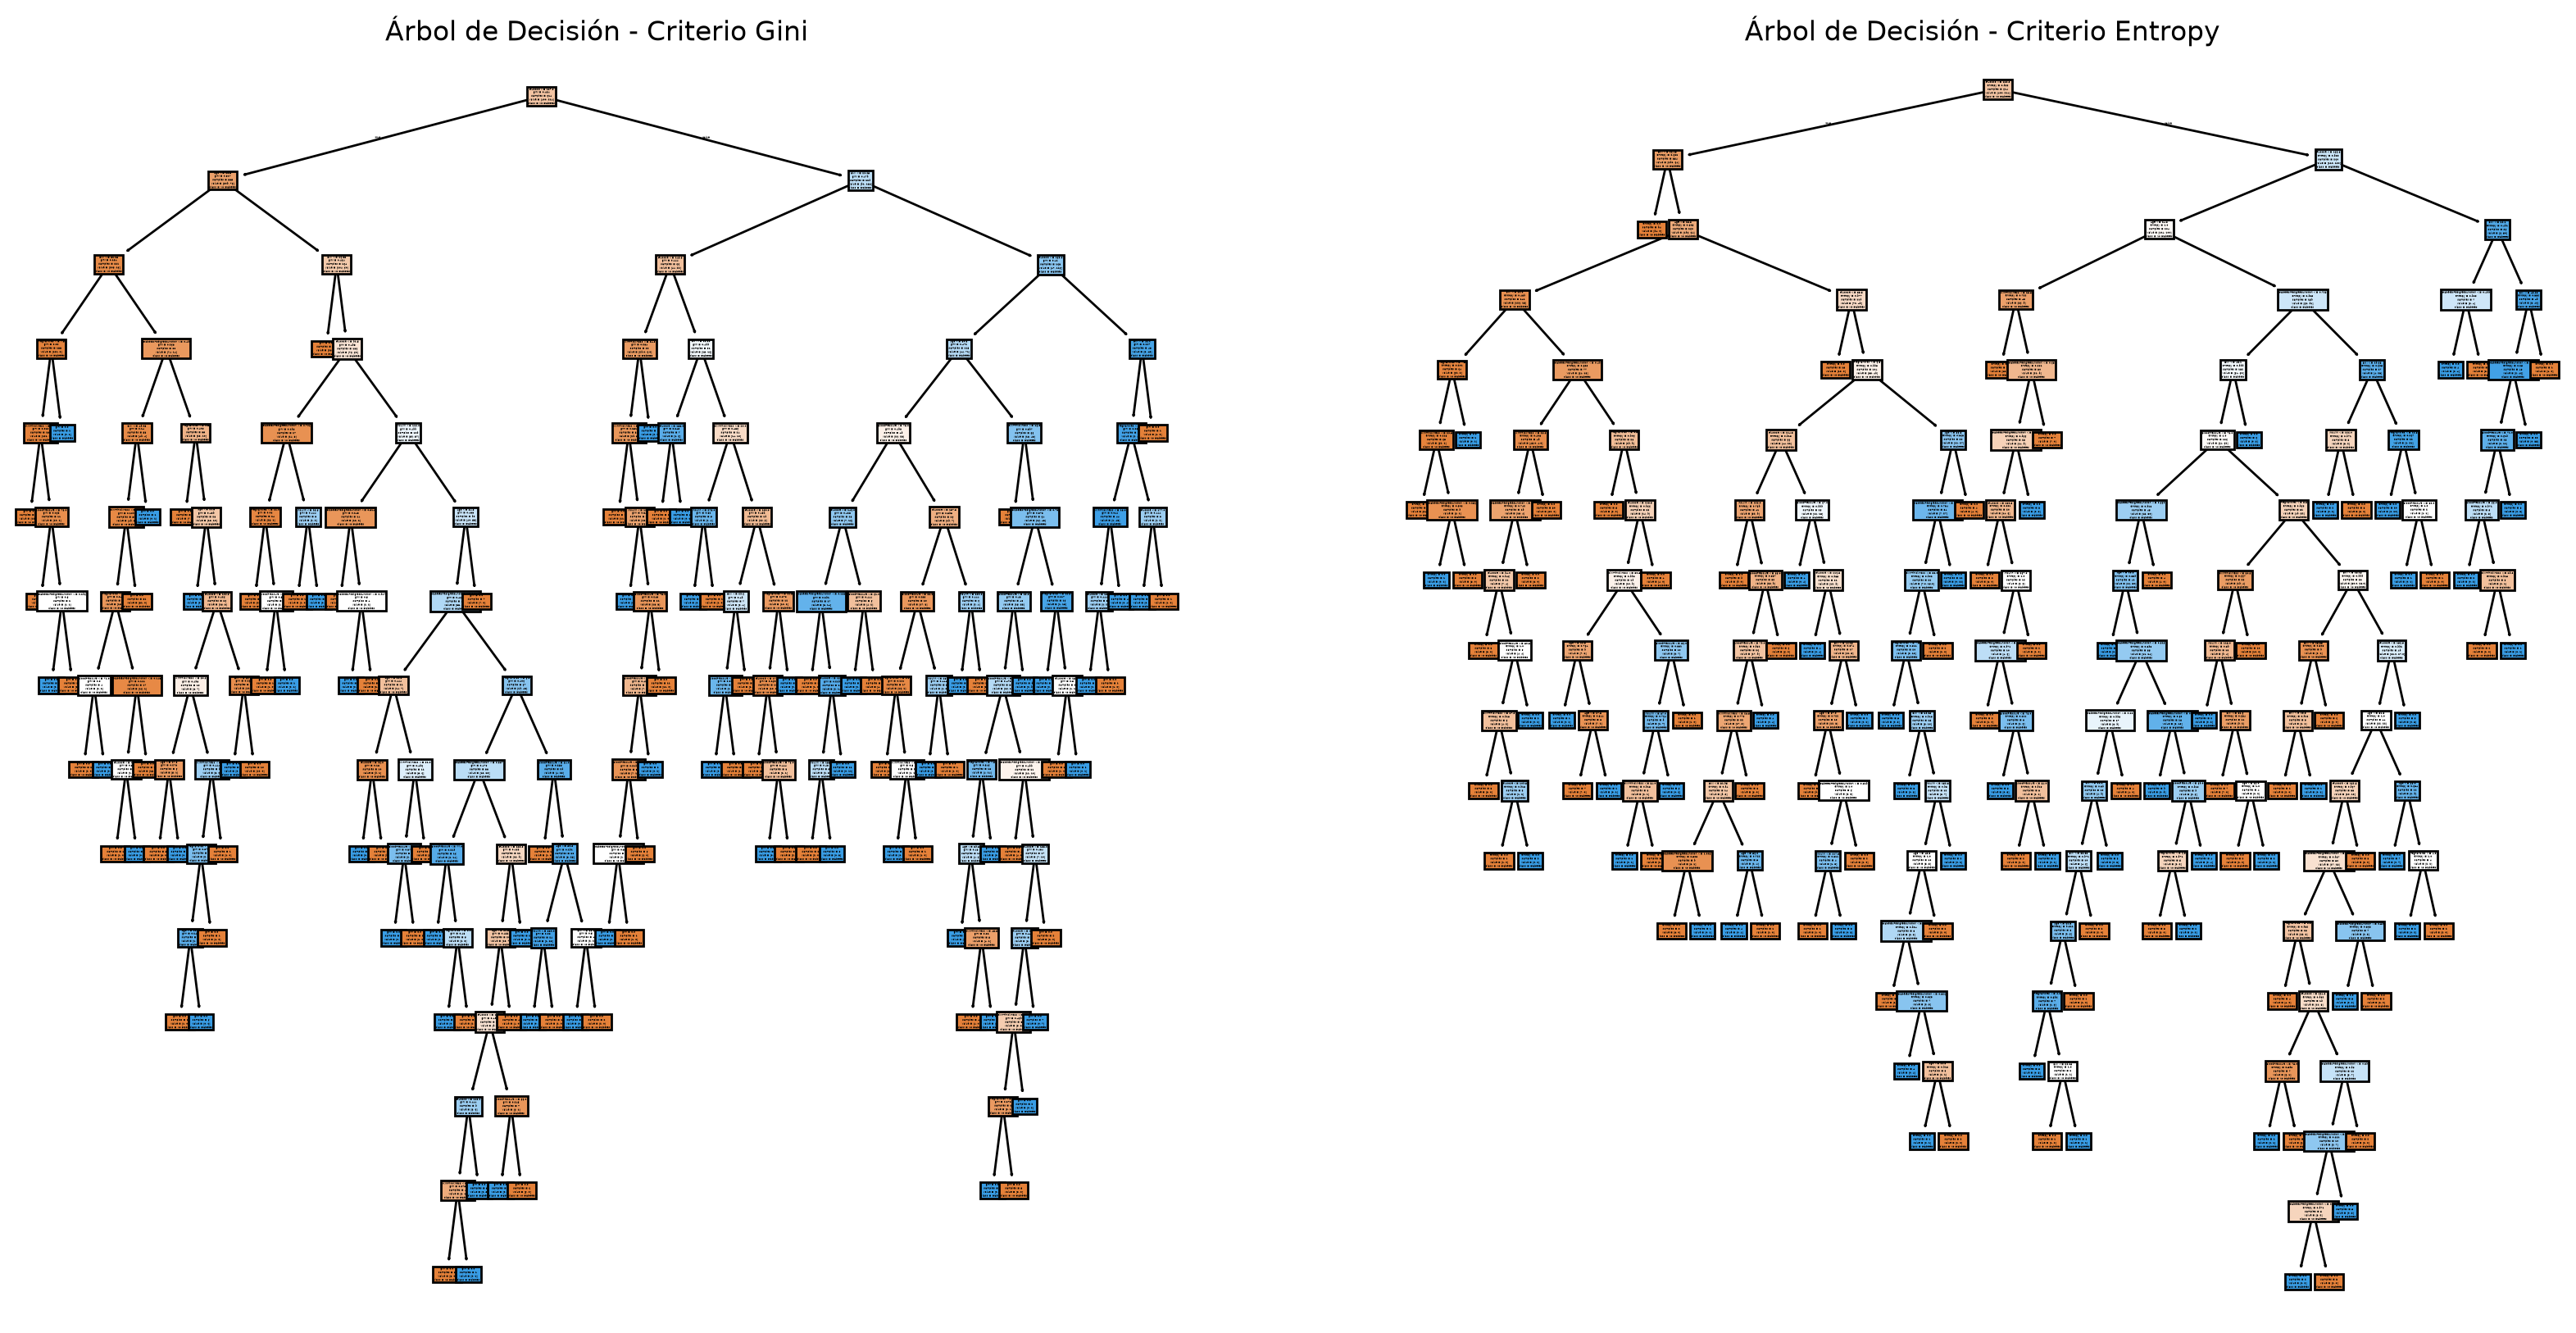

In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10), dpi=200)

# Graficar el árbol con Gini
plot_tree(model_gini, feature_names=X_train.columns, 
          class_names=["No Diabetes", "Diabetes"], filled=True, ax=axes[0])
axes[0].set_title("Árbol de Decisión - Criterio Gini")

# Graficar el árbol con Entropy
plot_tree(model_entropy, feature_names=X_train.columns, 
          class_names=["No Diabetes", "Diabetes"], filled=True, ax=axes[1])
axes[1].set_title("Árbol de Decisión - Criterio Entropy")

plt.show()

- **Visualización:** al graficar ambos árboles se nota que al no tener un límite de profundidad (max_depth), tienden a crecer bastante y volverse complejos (lo que suele generar sobreajuste o overfitting en los datos de entrenamiento).

### Optimiza el modelo anterior:

- Optimizamos hiperparámetros principales utilizando un grid search

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10, 20],
    "ccp_alpha": [0.0, 0.001, 0.005, 0.01],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=10),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",   
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print(f"Mejor accuracy en CV: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Mejores hiperparámetros: {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}
Mejor accuracy en CV: 0.7672


In [9]:
from sklearn.metrics import accuracy_score

# 6. Extraer el mejor modelo ya optimizado para usarlo en las pruebas
best_model = grid_search.best_estimator_

# 7. Calcular las predicciones para Train y Test
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)  # Asegúrate de usar el nombre correcto de tu conjunto de test

# 8. Calcular las exactitudes
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# 9. Mostrar los resultados comparativos finales
print("\n--- Rendimiento del Árbol de Decisión Optimizado ---")
print(f"Exactitud en Train: {train_accuracy:.4f}")
print(f"Exactitud en Test:  {test_accuracy:.4f}")
print(f"Brecha (Train - Test): {(train_accuracy - test_accuracy):.4f}")


--- Rendimiento del Árbol de Decisión Optimizado ---
Exactitud en Train: 0.8111
Exactitud en Test:  0.7597
Brecha (Train - Test): 0.0513


## Por último graficamos el arbol con la optimización de hiperparametros:

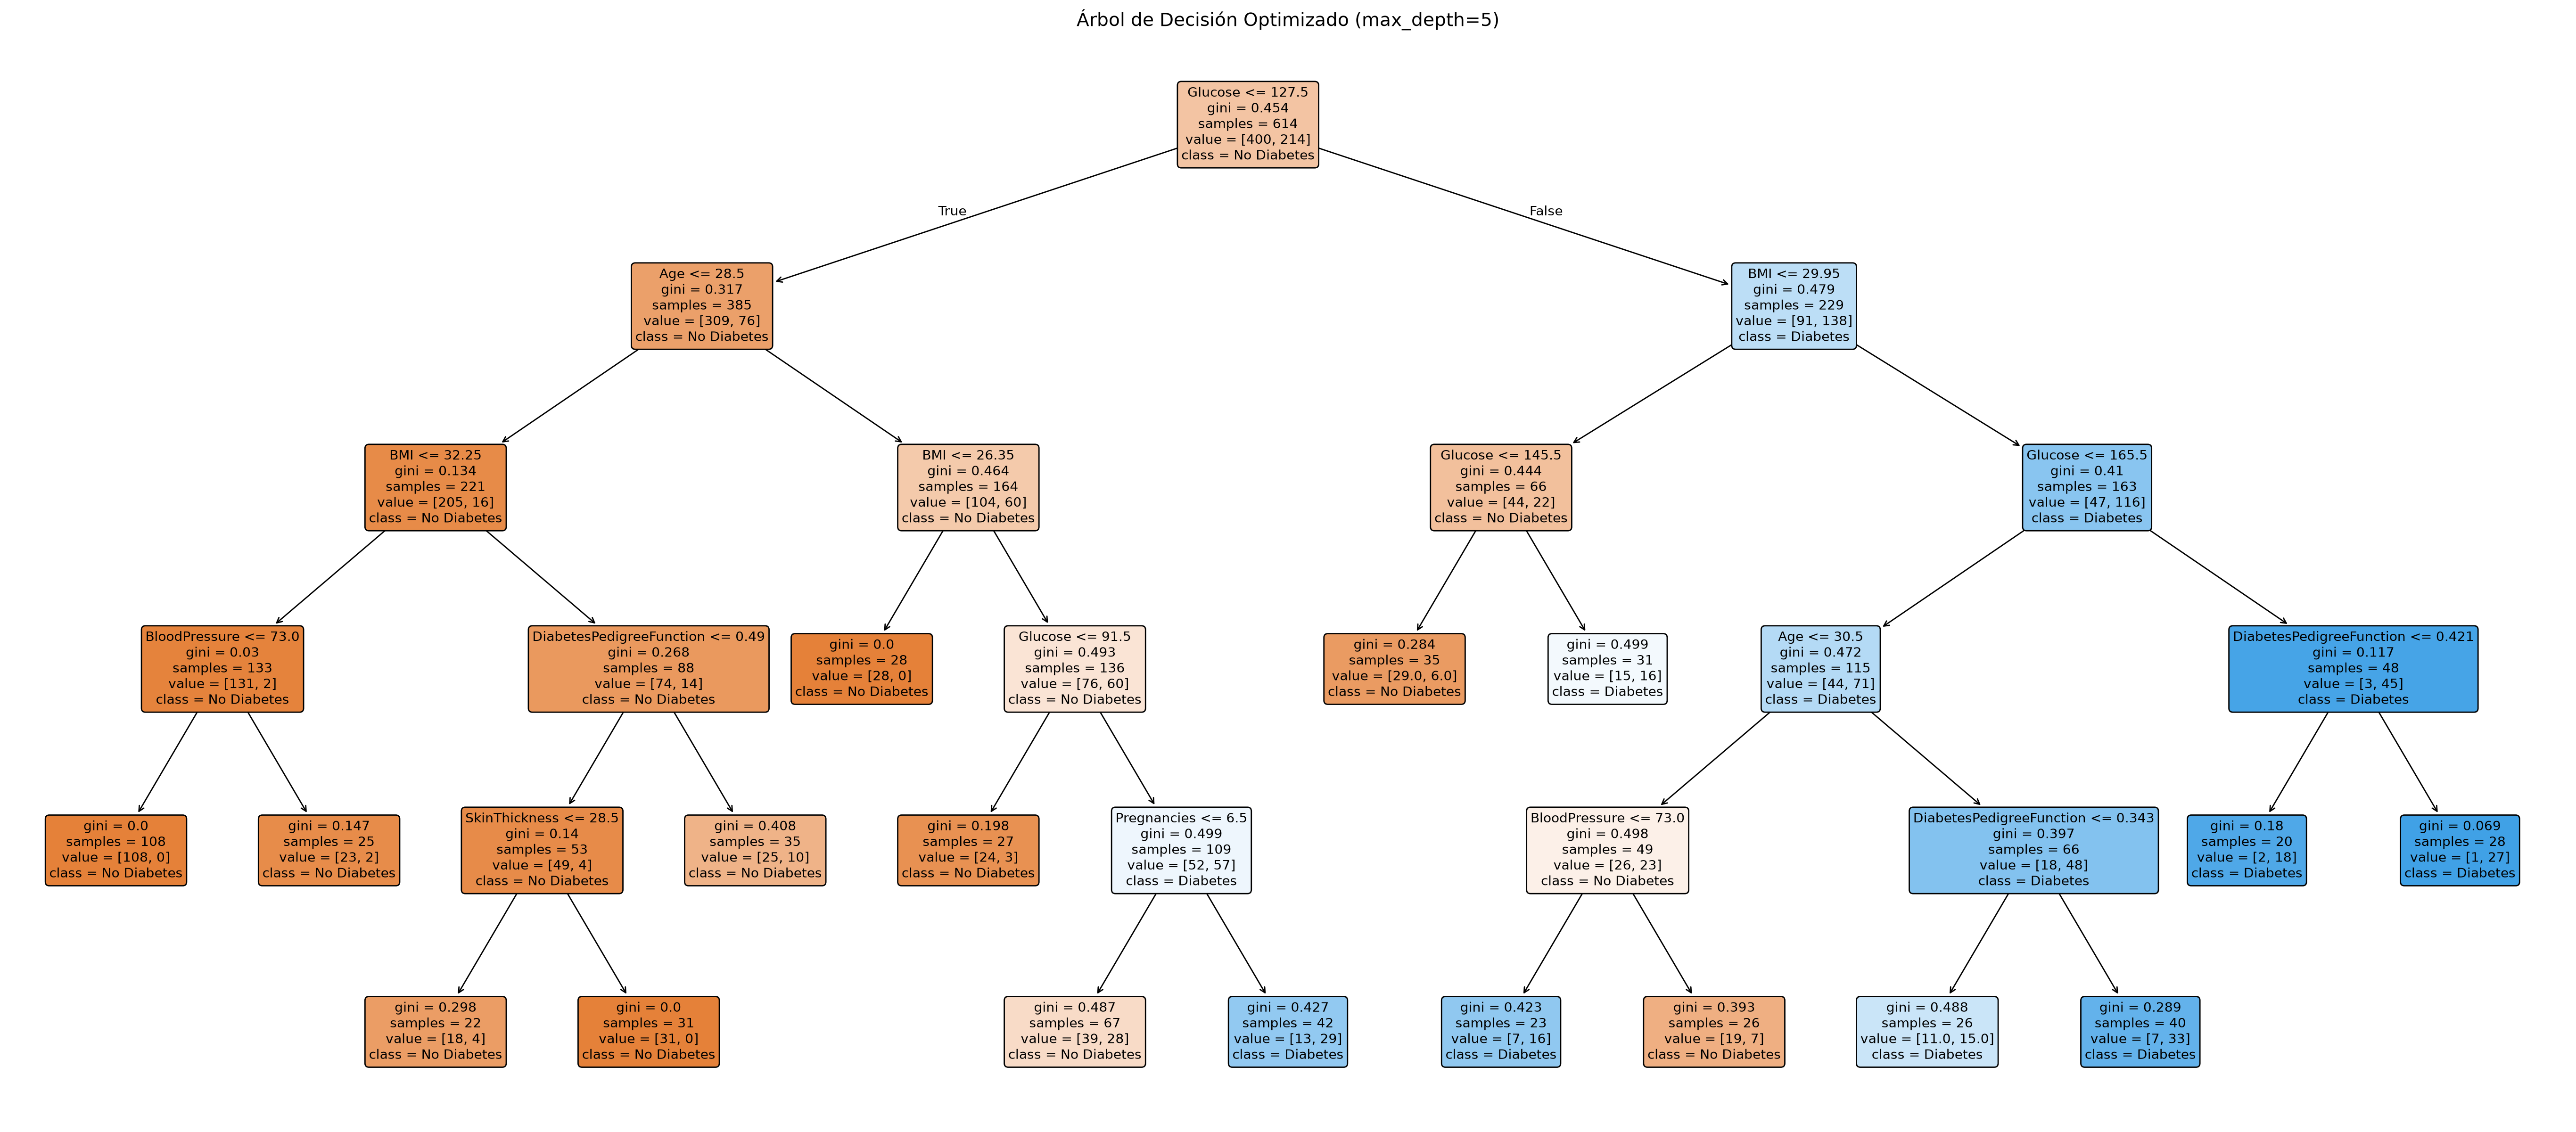

In [10]:
plt.figure(figsize=(35, 15), dpi=200)

# Graficamos el árbol definitivo
plot_tree(grid_search.best_estimator_,feature_names=X_train.columns,class_names=["No Diabetes", "Diabetes"],filled=True,rounded=True,fontsize=10)

plt.title("Árbol de Decisión Optimizado (max_depth=5)", fontsize=14)
plt.show()

### Conclusiones:
- El análisis comparativo del Árbol de Decisión sobre el dataset demuestra que, si bien un modelo base puede alcanzar una exactitud de accuracy en test (0.7078) pero en train evidencia un severo sobreajuste (1.000).
- Al aplicar una optimización de hiperparámetros mediante GridSearchCV, se logra un modelo que reduce drásticamente la brecha de rendimiento, estabilizando el comportamiento predictivo train (0.8111) y test (0.7597). 
- A continuación se recomienda realizar un random forest para intentar aumentar el accuracy.

## Radom Forest:
Paso 1: Importar y entrenar el Random Forest:

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Instanciamos el modelo con los parámetros por defecto
rf_model = RandomForestClassifier(random_state=42)

# Lo entrenamos
rf_model.fit(X_train, y_train)

# Evaluamos en el conjunto de TRAIN
y_pred_train = rf_model.predict(X_train)
acc_train = accuracy_score(y_train, y_pred_train)

# Evaluamos en el conjunto de TEST
y_pred_test = rf_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)

# Mostramos los resultados en consola
print(f"Precisión en Train: {acc_train:.4f}")
print(f"Precisión en Test:  {acc_test:.4f}")

Precisión en Train: 1.0000
Precisión en Test:  0.8117


- Al tener una precisión en train de 1.0 (100%) y la de test notablemente más baja con 0.8117 (81%) significa que el modelo tiene sobreajuste / overfitting).
- Modificaremos los dos hiperparámetros que definen al árbol con distintos valores y analizaremos su impacto con la precisión final y graficaremos las conclusiones:

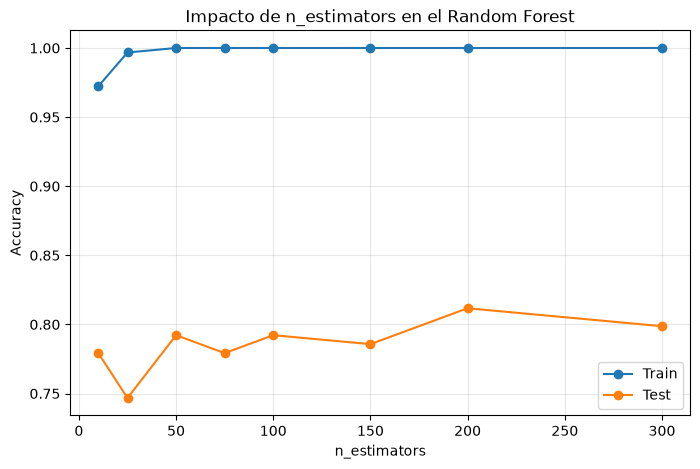

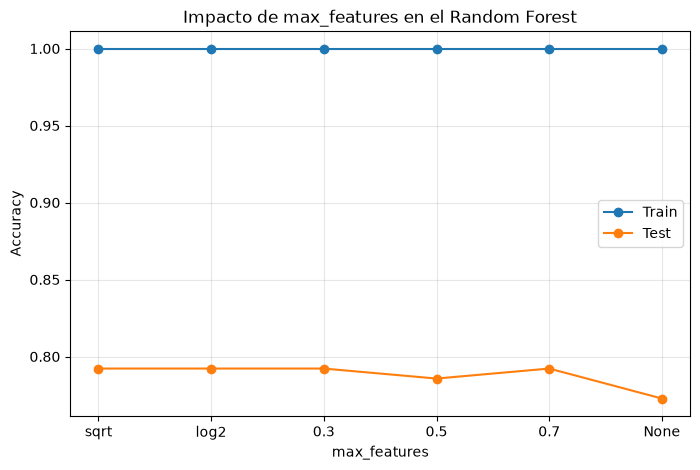

In [17]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- Impacto de n_estimators ---
valores_n_estimators = [10, 25, 50, 75, 100, 150, 200, 300]
acc_train_list, acc_test_list = [], []

for n in valores_n_estimators:
    modelo = RandomForestClassifier(n_estimators=n, random_state=10)
    modelo.fit(X_train, y_train)
    acc_train_list.append(accuracy_score(y_train, modelo.predict(X_train)))
    acc_test_list.append(accuracy_score(y_test, modelo.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(valores_n_estimators, acc_train_list, marker="o", label="Train")
plt.plot(valores_n_estimators, acc_test_list, marker="o", label="Test")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Impacto de n_estimators en el Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- Impacto de max_features ---
valores_max_features = ["sqrt", "log2", 0.3, 0.5, 0.7, None]
acc_train_list2, acc_test_list2 = [], []

for mf in valores_max_features:
    modelo = RandomForestClassifier(n_estimators=100, max_features=mf, random_state=10)
    modelo.fit(X_train, y_train)
    acc_train_list2.append(accuracy_score(y_train, modelo.predict(X_train)))
    acc_test_list2.append(accuracy_score(y_test, modelo.predict(X_test)))

plt.figure(figsize=(8, 5))
x_labels = [str(v) for v in valores_max_features]
plt.plot(x_labels, acc_train_list2, marker="o", label="Train")
plt.plot(x_labels, acc_test_list2, marker="o", label="Test")
plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("Impacto de max_features en el Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- **Impacto de `n_estimators`:** el accuracy en train se mantiene fijo en 1.0 para 
  cualquier cantidad de árboles. El accuracy en test, en cambio, oscila entre 0.75 y 
  0.81 sin una tendencia claramente ascendente a partir de ~50 árboles.

- **Impacto de `max_features`:** el accuracy en test se mantiene bastante estable 
  entre 0.77 y 0.79 para la mayoría de los valores probados, con la única caída 
  notable en `max_features=None` (0.77).

### Procedemos a realizar optimización de hiperparametros:

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
# Diccionario ampliado con más opciones para cada hiperparámetro
param_grid_ampliado = {
   'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    "class_weight": [None, "balanced"],
    'bootstrap': [True]
}

# Configuramos nuevamente el GridSearchCV con la misma estructura
grid_search_ampliado = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid_ampliado,cv=5,scoring='accuracy',n_jobs=-1,verbose=1)

# Ejecutamos con tus datos
grid_search_ampliado.fit(X_train, y_train)

# Resultados
print("Mejores hiperparámetros (versión ampliada):")
print(grid_search_ampliado.best_params_)
print(f"\nMejor precisión en validación cruzada: {grid_search_ampliado.best_score_:.4f}")

mejor_modelo_ampliado = grid_search_ampliado.best_estimator_

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Mejores hiperparámetros (versión ampliada):
{'bootstrap': True, 'class_weight': None, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}

Mejor precisión en validación cruzada: 0.7736


### Ahora usaremos estos hiperparametros para comparar el train con el test

In [13]:
y_pred_train_opt = mejor_modelo_ampliado.predict(X_train)
acc_train_opt = accuracy_score(y_train, y_pred_train_opt)

# Evaluamos el mejor modelo en el conjunto de prueba (test)
y_pred_test_opt = mejor_modelo_ampliado.predict(X_test)
acc_test_opt = accuracy_score(y_test, y_pred_test_opt)

# Calculamos la nueva diferencia
diferencia_opt = acc_train_opt - acc_test_opt

# Mostramos los resultados
print(f"Precisión en Train (Optimizado): {acc_train_opt:.4f}")
print(f"Precisión en Test (Optimizado):  {acc_test_opt:.4f}")
print(f"Diferencia (Train - Test):       {diferencia_opt:.4f}")

Precisión en Train (Optimizado): 0.9511
Precisión en Test (Optimizado):  0.8117
Diferencia (Train - Test):       0.1395


- Precisión con Árbol de Decisión simple test: 76% 
- Precisión con Random Forest test: 81%, el GridSearchCV no mejoró el accuracy de test respecto al Random Forest 
  por defecto (ambos 0.8117), pero sí redujo la brecha train-test de 0.1883 a 0.1395, produciendo menos sobreajuste.

### Graficamos los primeros tres arboles de las 50 estimaciones del random forest:

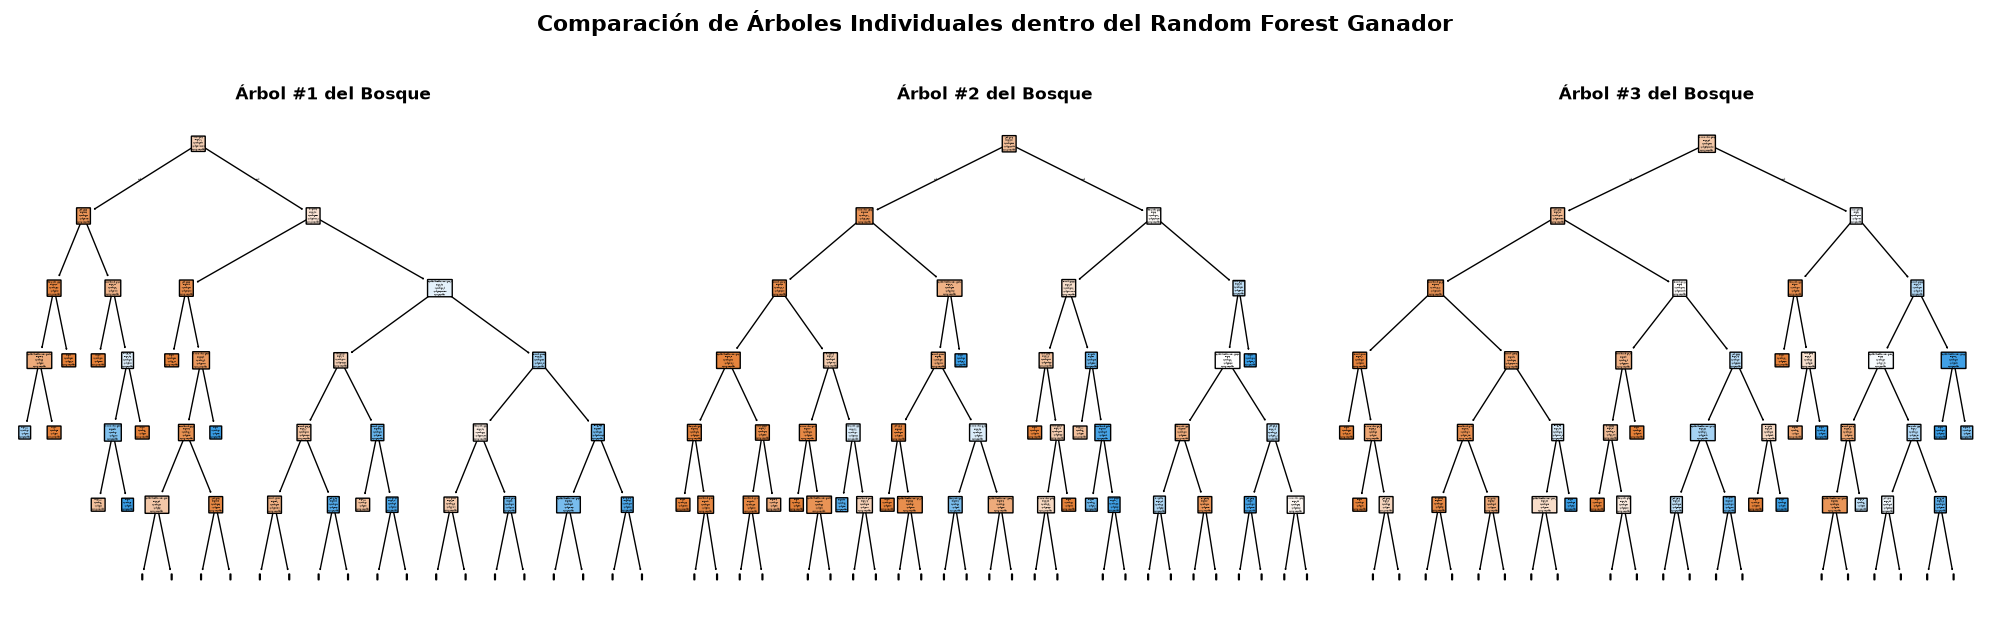

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Definimos cuántos árboles del bosque queremos visualizar
arboles_a_mostrar = 3

fig, axes = plt.subplots(1, arboles_a_mostrar, figsize=(20, 6))

for i, ax in enumerate(axes):
    # Extraemos el árbol i-ésimo del Random Forest
    un_arbol = mejor_modelo_ampliado.estimators_[i]
    
    plot_tree(un_arbol,feature_names=X_train.columns,class_names=['No Diabetes', 'Diabetes'],filled=True,rounded=True,max_depth=5,ax=ax)
    ax.set_title(f"Árbol #{i+1} del Bosque", fontsize=12, fontweight='bold')

plt.suptitle("Comparación de Árboles Individuales dentro del Random Forest Ganador", fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Conclusiones

**Random Forest:**
- Un Random Forest con hiperparámetros por defecto ya supera al árbol optimizado (test 0.8117 vs 0.7597), confirmando que combinar múltiples árboles  entrenados muestras mejora frente a un árbol individual.
- El análisis de `n_estimators` mostró que el accuracy en test no mejora de forma sostenida más allá de ~50 árboles, el de `max_features` confirmó que restringir la selección aleatoria de variables en cada split (`sqrt`, `log2`) funciona igual o mejor que usar todas las variables (`None`).
- La optimización con GridSearchCV (2160 combinaciones evaluadas) no mejoró el accuracy puntual en test (se mantuvo en 0.8117), pero sí redujo la brecha train-test de 0.1883 a 0.1395, entregando un modelo más robusto y menos propenso a sobreajuste ante datos nuevos.

**Conclusión general:**
El Random Forest resultó ser la mejor alternativa para este problema, con un accuracy en test de 81.17%, superando tanto al árbol base como al árbol optimizado. 